# HSLS Final SHAP + Error Analysis -- Set D V3 CatBoost

**Purpose:** Final explainability and error analysis of the selected HSLS model.

**Dataset:** HSLS:09 Set D (`prepared_hsls_setD_4Y.csv`) -- 12,829 records, 377 Set D
predictors.

**Target:** `program_stream` (`X4ENTRYMAJ4Y`).

**Predictors:** 377.

**Selected model:** V3 CatBoost -- imputed + scaled (fold-safe) + SMOTE, untuned
CatBoost, all 377 Set D predictors. This is the same frozen configuration documented in
`HSLS_catboost_experiment_SetD (2).ipynb`, reused here exactly, not reconstructed from
memory.

**Experimental role:** Final evaluation and explainability only. **V4, V5, and V6 are
NOT run in this notebook** -- this produces one final fitted V3 CatBoost model for
error analysis and SHAP, not another six-version experiment. No feature selection,
tuning, or new modelling family is introduced here. Cross-validation is **not**
recomputed here either -- it is loaded from the frozen Set D experiment's saved output
when available (see the CV section below), since retraining V3 CatBoost across CV
folds again would add significant runtime for no new evidence.

**Primary metric:** Macro-F1.

**Random state:** 42.

**Inputs used, and how:**
- `prepared_hsls_setD_4Y.csv` -- the modelling dataset (Set D, 377 predictors).
- `HSLS_final_predictor_decision_table.csv` -- cross-check that this dataset's
  predictor set matches the approved Set D list (377 variables); an integrity check
  below asserts an exact set match rather than only a count match.
- `HSLS_SetE_feature_audit.csv` -- used **only** as a reference for HSLS variable
  descriptions and the corrected educational dimension (`Corrected Set E Dimension`
  column), for interpreting SHAP results. This file covers all 377 Set D predictors
  (332 kept + 45 removed in Set E), not just the 332-predictor Set E subset -- verified
  by an integrity check below. **Not used to select, remove, or reweight any
  predictor** -- the modelling feature set remains the full 377 Set D predictors.
- `catboost_svm_replacement_v1_v1_v2_v3_per_model_results.csv` (optional) -- if
  present, V3 CatBoost's documented CV Macro-F1 mean/SD is loaded from here instead of
  being recomputed.
- `X4ENTRYMAJ4Y_label_mapping.csv` (optional) -- if present, supplies human-readable
  major-group names for the encoded target classes. If absent, encoded values are used
  throughout and a blank template is saved for you to fill in -- **no label is
  invented**.

**Reproducibility note:** documented frozen V3 test Macro-F1 = **0.2287**. This value is
a previously documented reference result, quoted here for comparison only. It is not
hard-coded into any calculation below -- the notebook reproduces its own Macro-F1 from
the fitted model and compares the two, flagging (not silently absorbing) any material
discrepancy.

**On H2:** this notebook calculates and prints dimension-level SHAP evidence only. It
does **not** automatically classify H2 as Supported/Partially Supported/Not Supported --
that decision is left to be made explicitly, based on the results below, reported
cautiously.

**This is the FINAL version.** Class labels for the 11 `X4ENTRYMAJ4Y` categories and
the Top-30 SHAP-to-dimension mapping have both been manually verified (not
automated) and are applied throughout. The model is **not** refit and SHAP is **not**
recomputed relative to the prior notebook -- this version applies verified labels and
a verified dimension mapping to the same single model fit / SHAP computation, as an
interpretation and presentation correction only.


## (Optional) Mount Google Drive
Run this if the paths below point to files in Google Drive.

In [22]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Colab -- skipping Drive mount (expected for local VS Code runs).")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Install / Import

In [23]:
!pip install imbalanced-learn --quiet
!pip install catboost --quiet
!pip install shap --quiet

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from catboost import CatBoostClassifier
import shap


### CONFIG

Identical `DATA_PATH`, `TARGET_COL`, `RANDOM_STATE`, and `CATBOOST_DEFAULTS` to
`HSLS_catboost_experiment_SetD (2).ipynb` -- nothing here is a new choice.

In [24]:
DATA_PATH      = "/content/drive/MyDrive/clean files/prepared_hsls_setD_4Y (3).csv"   # same file as the frozen V3 experiment
TARGET_COL     = "program_stream"
COLS_TO_REMOVE = []
RANDOM_STATE   = 42

EXPERIMENT_TAG = "/content/drive/MyDrive/clean files/SHAP_ErrorAnalysis_setD_v3"

# Reference-only inputs -- used for description/dimension lookup and a predictor-list
# cross-check, never to change the modelling feature set.
DECISION_TABLE_PATH = "/content/drive/MyDrive/clean files/HSLS_final_predictor_decision_table.csv"   # 377-variable cross-check
SETE_AUDIT_PATH      = "/content/drive/MyDrive/clean files/HSLS_SetE_feature_audit.csv"              # description + dimension reference, covers all 377

# Frozen Set D experiment's saved per-model results -- used to load V3 CatBoost's
# documented CV Macro-F1 mean/SD instead of recomputing it here.
SET_D_EXPERIMENT_TAG = "/content/drive/MyDrive/clean files/catboost_svm_replacement_v1"
SET_D_PER_MODEL_RESULTS_PATH = f"{SET_D_EXPERIMENT_TAG}_v1_v2_v3_per_model_results.csv"
RERUN_CV_IF_UNAVAILABLE = False   # if the file above is missing, skip CV rather than block SHAP

# Optional human-readable label mapping for X4ENTRYMAJ4Y's encoded classes. If this file
# doesn't exist, encoded values are used everywhere and a blank template is saved for
# review -- no label is invented.
LABEL_MAPPING_PATH = "/content/drive/MyDrive/clean files/X4ENTRYMAJ4Y_label_mapping.csv"

# All CSVs and figures this notebook saves are written under OUTPUT_DIR, not the
# notebook's default working directory -- so results land in the same Drive folder as
# the input files above instead of Colab's ephemeral /content/.
OUTPUT_DIR = "/content/drive/MyDrive/clean files/output3"

def out_path(filename: str) -> str:
    """Join a bare output filename onto OUTPUT_DIR."""
    return f"{OUTPUT_DIR.rstrip('/')}/{filename}"

# Documented reference result from the frozen V3 experiment -- comparison only, never
# substituted for a calculated value below.
DOCUMENTED_V3_MACRO_F1 = 0.2287
REPRODUCTION_TOLERANCE = 0.02   # absolute Macro-F1 difference treated as "material"

# Identical CatBoost defaults to the frozen V3 experiment.
CATBOOST_DEFAULTS = dict(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    l2_leaf_reg=3.0,
    early_stopping_rounds=30,
    val_size=0.15,
    random_state=RANDOM_STATE,
    verbose=False,
)

# Final analytical dimensions used to aggregate SHAP results (interpretation only --
# does not change which predictors are modelled). Mapped from HSLS_SetE_feature_audit's
# "Corrected Set E Dimension" column, which already used exactly these categories
# (renamed slightly here to the thesis's final dimension labels).
DIMENSION_RENAME = {
    "Academic performance": "Academic performance/preparation",
    "Career interests and aspirations": "Career interests and aspirations",
    "Skills and self-efficacy": "Skills and self-efficacy",
    "Behavioral or psychological factors": "Behavioral/psychological factors",
    "Demographic or socioeconomic controls": "Demographic/SES controls",
}


### SHARED: load data, evaluation helpers, CatBoost wrapper, preprocessing

**Copied verbatim from `HSLS_catboost_experiment_SetD (2).ipynb`** -- not reconstructed.
Only `BASE_MODEL_DEFS` is trimmed to CatBoost alone below, since this notebook fits one
final model rather than comparing five.

In [25]:
def load_data(path: str, target_col: str, cols_to_remove: list) -> pd.DataFrame:
    df = pd.read_csv(path)
    present = [c for c in cols_to_remove if c in df.columns]
    if present:
        df = df.drop(columns=present)
    if df[target_col].isnull().sum() > 0:
        before = len(df)
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        print(f"Dropped {before - len(df)} rows with missing target.")
    print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
    return df


def diagnose(f1_train, f1_test):
    gap = f1_train - f1_test
    if gap > 0.15:
        return gap, "OVERFIT"
    elif f1_test < 0.50 and f1_train < 0.50:
        return gap, "UNDERFIT"
    return gap, "GOOD FIT"


def evaluate(model, X_train, y_train, X_test, y_test, cv, name, extra=None):
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_test = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_train = f1_score(y_train, y_train_pred, average="macro", zero_division=0)
    gap, diag = diagnose(f1_train, f1_test)

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    row = {
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Test": round(f1_test, 4),
        "F1 Train": round(f1_train, 4),
        "Train-Test Gap": round(gap, 4),
        "CV Mean": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
        "Diagnosis": diag,
    }
    if extra:
        row.update(extra)
    return row


class CatBoostEarlyStop(BaseEstimator, ClassifierMixin):
    """CatBoost wrapper with SELF-CONTAINED early stopping.

    Carves its own train/validation split out of whatever X, y it is given at .fit()
    time -- and .fit() is only ever called with TRAINING data (a pipeline's training
    fold, a CV fold's training portion, or GridSearchCV's per-fold training split). It
    never receives the outer held-out test set, so the test set can never leak into
    early stopping -- no fit_params plumbing through Pipeline/GridSearchCV/
    cross_val_score is needed, because the validation carve-out happens INSIDE this
    estimator, transparently, every place it is fit.

    Exposes the standard sklearn estimator API (get_params/set_params via
    BaseEstimator, fit/predict/predict_proba) so it drops into the existing
    ImbPipeline/SkPipeline/GridSearchCV/cross_val_score call sites with no other code
    changes required in V1-V6.
    """

    def __init__(self, iterations=500, depth=6, learning_rate=0.1,
                 l2_leaf_reg=3.0, early_stopping_rounds=30,
                 val_size=0.15, random_state=42, verbose=False):
        self.iterations = iterations
        self.depth = depth
        self.learning_rate = learning_rate
        self.l2_leaf_reg = l2_leaf_reg
        self.early_stopping_rounds = early_stopping_rounds
        self.val_size = val_size
        self.random_state = random_state
        self.verbose = verbose

    def _build_model(self):
        return CatBoostClassifier(
            iterations=self.iterations,
            depth=self.depth,
            learning_rate=self.learning_rate,
            l2_leaf_reg=self.l2_leaf_reg,
            random_state=self.random_state,
            verbose=self.verbose,
            loss_function="MultiClass",
        )

    def fit(self, X, y):
        y = np.asarray(y)
        min_class_count = pd.Series(y).value_counts().min()
        try:
            if min_class_count < 2:
                raise ValueError("class too small to stratify")
            X_tr, X_val, y_tr, y_val = train_test_split(
                X, y, test_size=self.val_size, random_state=self.random_state, stratify=y
            )
        except ValueError:
            X_tr, X_val, y_tr, y_val = train_test_split(
                X, y, test_size=self.val_size, random_state=self.random_state
            )

        self.model_ = self._build_model()
        self.model_.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=self.early_stopping_rounds,
            use_best_model=True,
            verbose=self.verbose,
        )
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return np.asarray(self.model_.predict(X)).ravel()

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


BASE_MODEL_DEFS = lambda: {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "CatBoost": CatBoostEarlyStop(**CATBOOST_DEFAULTS),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
}
# CHANGED FROM OFFICIAL PIPELINE: "SVM": SVC(...) is replaced by "CatBoost":
# CatBoostEarlyStop(...) above. Decision Tree, Random Forest, KNN, Naive Bayes
# are byte-for-byte identical to the official file.


def smote_k_for(y_train):
    min_class_count = pd.Series(y_train).value_counts().min()
    return max(1, min(5, min_class_count - 1))


def make_cv(y):
    """StratifiedKFold with n_splits capped by the smallest class's size, not
    hardcoded to 5. A class with only 2-3 members (common in imbalanced multi-class
    data) can't support 5-fold CV; this adapts instead of silently erroring deep
    inside sklearn or, worse, running with folds that don't actually contain every
    class."""
    min_class_count = pd.Series(y).value_counts().min()
    n_splits = min(5, int(min_class_count))
    if n_splits < 2:
        raise ValueError(
            f"Cross-validation impossible: smallest class has only "
            f"{min_class_count} sample(s), need at least 2 for any CV split."
        )
    if n_splits < 5:
        print(f"  NOTE: smallest class has {min_class_count} samples -- "
              f"using {n_splits}-fold CV instead of the default 5-fold.")
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


class ColumnIndexSelector(BaseEstimator, TransformerMixin):
    """Selects fixed column positions from an already-preprocessed array. Used by V4
    to apply its one-time feature ranking (chi2/RFE/RF-importance, computed once --
    exploratory, matches the original V4 design) inside a pipeline whose
    IMPUTATION/ENCODING/SCALING still gets refit fresh per CV fold. Only the selected
    feature *positions* are fixed in advance; the preprocessing that produces those
    positions' values is not."""
    def __init__(self, indices):
        self.indices = indices
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[:, self.indices]


def determine_column_types(df_train_raw: pd.DataFrame, target_col: str):
    """Classifies each predictor as continuous/discrete/categorical from the training
    schema. This is a one-time STRUCTURAL decision, not a fold-sensitive statistic --
    safe to do once outside CV."""
    numeric_cols = df_train_raw.select_dtypes(include="number").columns.tolist()
    categorical_cols = [c for c in df_train_raw.select_dtypes(include="object").columns if c != target_col]
    continuous_cols, discrete_cols = [], []
    for col in numeric_cols:
        if col == target_col:
            continue
        non_null = df_train_raw[col].dropna()
        is_integer = non_null.apply(lambda x: x == int(x)).all() if len(non_null) else True
        n_unique = df_train_raw[col].nunique()
        if is_integer and n_unique <= 20:
            discrete_cols.append(col)
        else:
            continuous_cols.append(col)
    return continuous_cols, discrete_cols, categorical_cols


def build_preprocessor(continuous_cols, discrete_cols, categorical_cols):
    """Unfitted ColumnTransformer: mean-impute continuous, median-impute discrete,
    mode-impute + ordinal-encode categorical (unseen categories map to -1). Nothing is
    fit here -- fitting happens fresh each time this is cloned into a Pipeline and
    that Pipeline is fit, which is what makes this fold-safe."""
    continuous_pipe = SkPipeline([("impute", SimpleImputer(strategy="mean"))])
    discrete_pipe = SkPipeline([("impute", SimpleImputer(strategy="median"))])
    categorical_pipe = SkPipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer(transformers=[
        ("cont", continuous_pipe, continuous_cols),
        ("disc", discrete_pipe, discrete_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])


# Trimmed to CatBoost only -- this notebook fits ONE final model, not a five-model
# comparison. Construction of the CatBoost estimator itself (CatBoostEarlyStop with
# CATBOOST_DEFAULTS) is identical to the frozen experiment.
def make_frozen_catboost():
    return CatBoostEarlyStop(**CATBOOST_DEFAULTS)


### SHARED: V2/V3-style preprocessing split

**Copied verbatim from `HSLS_catboost_experiment_SetD (2).ipynb`.**

In [26]:
def prepare_v2_style(df: pd.DataFrame):
    """Split BEFORE any preprocessing. Only column TYPES (continuous/discrete/
    categorical) are determined here -- a structural decision, not a fold-sensitive
    statistic. Returns the raw train/test feature frames plus a make_preprocessor()
    factory that builds a fresh, unfitted ColumnTransformer, so imputation/encoding/
    scaling statistics get refit on only the training portion of each CV fold."""
    target_missing = df[TARGET_COL].isnull().sum()
    if target_missing > 0:
        df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

    train_idx, test_idx = train_test_split(
        df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=df[TARGET_COL]
    )
    df_train_raw = df.loc[train_idx].copy()
    df_test_raw = df.loc[test_idx].copy()

    continuous_cols, discrete_cols, categorical_cols = determine_column_types(df_train_raw, TARGET_COL)
    feature_names = continuous_cols + discrete_cols + categorical_cols

    X_train_raw = df_train_raw[feature_names]
    X_test_raw = df_test_raw[feature_names]

    le_target = LabelEncoder()
    le_target.fit(df_train_raw[TARGET_COL])
    y_train = le_target.transform(df_train_raw[TARGET_COL])
    y_test = le_target.transform(df_test_raw[TARGET_COL])

    n_features = len(feature_names)
    K15 = min(15, n_features)
    K20 = min(20, n_features)
    K50 = min(50, n_features)
    K100 = min(100, n_features)
    print(f"Available predictors: {n_features} (continuous={len(continuous_cols)}, "
          f"discrete={len(discrete_cols)}, categorical={len(categorical_cols)})")
    print(f"V4 small feature set (K15): {K15}")
    print(f"V4/V5/V6 feature set (K20): {K20}")
    print(f"V4 expanded feature set (K50): {K50}")
    print(f"V4 expanded feature set (K100): {K100}")

    def make_preprocessor():
        return build_preprocessor(continuous_cols, discrete_cols, categorical_cols)

    return {
        "X_train_raw": X_train_raw,
        "X_test_raw": X_test_raw,
        "y_train": y_train,
        "y_test": y_test,
        "feature_names": feature_names,
        "make_preprocessor": make_preprocessor,
        "le_target": le_target,
        "n_features": n_features,
        "K15": K15, "K20": K20, "K50": K50, "K100": K100,
    }


### Predictor-set integrity check

Confirms this dataset's 377 predictor columns are an **exact set match** against the
approved Set D decision table -- not just a count match -- before any modelling or SHAP
work proceeds.

In [27]:
if os.path.exists(DECISION_TABLE_PATH):
    decision_table = pd.read_csv(DECISION_TABLE_PATH)
    approved_vars = set(decision_table["Variable"])
    dataset_predictor_cols = set(pd.read_csv(DATA_PATH, nrows=0).columns) - {TARGET_COL}

    missing_from_dataset = approved_vars - dataset_predictor_cols
    unexpected_in_dataset = dataset_predictor_cols - approved_vars

    print(f"Decision table predictors: {len(approved_vars)}")
    print(f"Dataset predictor columns: {len(dataset_predictor_cols)}")
    print(f"Approved variables missing from dataset: {len(missing_from_dataset)} {sorted(missing_from_dataset) if missing_from_dataset else ''}")
    print(f"Dataset columns not in decision table: {len(unexpected_in_dataset)} {sorted(unexpected_in_dataset) if unexpected_in_dataset else ''}")

    if missing_from_dataset or unexpected_in_dataset:
        print("\n*** WARNING: dataset predictor set does not exactly match the approved "
              "Set D decision table. Investigate before trusting downstream results. ***")
    else:
        print("\nExact match: dataset predictor set == approved Set D decision table.")
else:
    print(f"NOTE: '{DECISION_TABLE_PATH}' not found -- skipping predictor-set cross-check "
          f"(not required for modelling, only for this integrity check).")


Decision table predictors: 377
Dataset predictor columns: 377
Approved variables missing from dataset: 0 
Dataset columns not in decision table: 0 

Exact match: dataset predictor set == approved Set D decision table.


### Human-readable class labels (VERIFIED)

The encoded `program_stream` classes 0-10 correspond to documented NCES
`X4ENTRYMAJ4Y` categories. This mapping has been manually verified (not inferred or
automated) and is written to `X4ENTRYMAJ4Y_label_mapping.csv`, then used throughout --
confusion matrix, classification report, confusion-pair table, local SHAP explanation
titles, and the final summary. The encoded target values themselves are never changed;
only the display labels.

In [28]:
VERIFIED_LABEL_MAP = {
    0: "Undeclared/undecided",
    1: "Computer and information sciences",
    2: "Engineering and engineering technology",
    3: "Biological & physical sciences, science technologies, mathematics, agriculture",
    4: "General studies and other",
    5: "Social sciences",
    6: "Humanities",
    7: "Health care fields",
    8: "Business",
    9: "Education",
    10: "Other applied",
}

label_map_df = pd.DataFrame(
    {"Encoded Value": list(VERIFIED_LABEL_MAP.keys()), "Label": list(VERIFIED_LABEL_MAP.values())}
)
label_map_df.to_csv(out_path("X4ENTRYMAJ4Y_label_mapping.csv"), index=False)
CLASS_LABELS = VERIFIED_LABEL_MAP
print("Saved verified class-label mapping: X4ENTRYMAJ4Y_label_mapping.csv")
print(label_map_df.to_string(index=False))

def display_label(encoded_value):
    """Verified human-readable label for a known encoded value; falls back to the
    encoded value itself only if it is unexpectedly outside 0-10 (should not occur)."""
    return str(CLASS_LABELS.get(encoded_value, encoded_value))


Saved verified class-label mapping: X4ENTRYMAJ4Y_label_mapping.csv
 Encoded Value                                                                          Label
             0                                                           Undeclared/undecided
             1                                              Computer and information sciences
             2                                         Engineering and engineering technology
             3 Biological & physical sciences, science technologies, mathematics, agriculture
             4                                                      General studies and other
             5                                                                Social sciences
             6                                                                     Humanities
             7                                                             Health care fields
             8                                                                       Bu

### Fit the frozen V3 CatBoost configuration

**Adapted from `run_v3` in `HSLS_catboost_experiment_SetD (2).ipynb`** -- identical
pipeline construction (`preprocess -> scale -> smote -> model`), identical SMOTE
placement (training fold only), identical CatBoost settings, scoped to CatBoost alone
and returning the **fitted pipeline object** (needed for SHAP and error analysis)
instead of only a metrics row. Cross-validation is intentionally **not** computed
inside this function -- see the CV section below.

In [29]:
def fit_frozen_v3_catboost(prep: dict):
    print("\n" + "=" * 70)
    print("Fitting frozen V3 CatBoost (imputed + scaled + SMOTE, all 377 predictors)")
    print("=" * 70)

    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    smote_k = smote_k_for(y_train)
    print(f"SMOTE k_neighbors={smote_k}")

    pipe = ImbPipeline([
        ("preprocess", prep["make_preprocessor"]()),
        ("scale", MinMaxScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
        ("model", make_frozen_catboost()),
    ])
    pipe.fit(X_train, y_train)

    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)

    f1_test = f1_score(y_test, y_pred_test, average="macro", zero_division=0)
    f1_train = f1_score(y_train, y_pred_train, average="macro", zero_division=0)
    row = {
        "Model": "CatBoost (frozen V3)",
        "Accuracy": round(accuracy_score(y_test, y_pred_test), 4),
        "Precision": round(precision_score(y_test, y_pred_test, average="macro", zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_test, average="macro", zero_division=0), 4),
        "F1 Test": round(f1_test, 4),
        "F1 Train": round(f1_train, 4),
        "Train-Test Gap": round(f1_train - f1_test, 4),
    }
    return pipe, y_pred_test, row, smote_k


## Load data, prepare, and fit the frozen model

In [30]:
df = load_data(DATA_PATH, TARGET_COL, COLS_TO_REMOVE)
prep = prepare_v2_style(df)
pipe, y_pred_test, v3_row, smote_k = fit_frozen_v3_catboost(prep)


Loaded: 12829 rows x 378 columns
Available predictors: 377 (continuous=42, discrete=335, categorical=0)
V4 small feature set (K15): 15
V4/V5/V6 feature set (K20): 20
V4 expanded feature set (K50): 50
V4 expanded feature set (K100): 100

Fitting frozen V3 CatBoost (imputed + scaled + SMOTE, all 377 predictors)
SMOTE k_neighbors=5


## Reproduce the selected model and check against the documented reference

The Macro-F1 check below **compares** the freshly calculated test Macro-F1 to the
documented reference (0.2287) -- it does not force, adjust, or substitute the
calculated value. Cross-validation is **loaded from the frozen Set D experiment's
saved output** rather than recomputed (retraining V3 CatBoost across CV folds again
would add significant runtime for no new evidence); if that file isn't available, CV is
skipped rather than blocking the rest of the notebook.

In [31]:
target_classes = sorted(pd.unique(np.concatenate([prep["y_train"], prep["y_test"]])).tolist())
class_distribution = pd.Series(np.concatenate([prep["y_train"], prep["y_test"]])).value_counts().sort_index()

# Save a blank label-mapping template now that target_classes is known, if no mapping
# was loaded above -- for the person to fill in, not for this notebook to invent.
if not CLASS_LABELS:
    template = pd.DataFrame({"Encoded Value": target_classes, "Label": [""] * len(target_classes)})
    template.to_csv(out_path("X4ENTRYMAJ4Y_label_mapping_TEMPLATE.csv"), index=False)
    print(f"Saved blank label template: X4ENTRYMAJ4Y_label_mapping_TEMPLATE.csv "
          f"(fill in 'Label' from the HSLS codebook, save as '{LABEL_MAPPING_PATH}', and re-run).")

# --- CV: load from the frozen Set D experiment rather than recompute ---
cv_mean, cv_std, cv_source = None, None, None
if os.path.exists(SET_D_PER_MODEL_RESULTS_PATH):
    setd_results = pd.read_csv(SET_D_PER_MODEL_RESULTS_PATH)
    v3_catboost_row = setd_results[(setd_results["Version"] == "V3") & (setd_results["Model"] == "CatBoost")]
    if len(v3_catboost_row) == 1 and "CV Mean" in v3_catboost_row.columns:
        cv_mean = float(v3_catboost_row["CV Mean"].iloc[0])
        cv_std = float(v3_catboost_row["CV Std"].iloc[0])
        cv_source = f"loaded from frozen Set D experiment ('{SET_D_PER_MODEL_RESULTS_PATH}')"
    else:
        print(f"NOTE: '{SET_D_PER_MODEL_RESULTS_PATH}' found but no matching V3/CatBoost "
              f"row with CV columns -- CV will be handled per RERUN_CV_IF_UNAVAILABLE.")
else:
    print(f"NOTE: '{SET_D_PER_MODEL_RESULTS_PATH}' not found.")

if cv_mean is None and RERUN_CV_IF_UNAVAILABLE:
    print("Recomputing CV in this notebook (RERUN_CV_IF_UNAVAILABLE=True) -- this retrains "
          "V3 CatBoost across folds and will take a while.")
    cv = make_cv(prep["y_train"])
    cv_scores = cross_val_score(pipe, prep["X_train_raw"], prep["y_train"], cv=cv, scoring="f1_macro", n_jobs=-1)
    cv_mean, cv_std = float(cv_scores.mean()), float(cv_scores.std())
    cv_source = "recomputed in this notebook"
elif cv_mean is None:
    cv_source = "not available (frozen Set D CV file not found; RERUN_CV_IF_UNAVAILABLE=False, so CV was skipped)"

print(f"\nTotal records:              {len(prep['y_train']) + len(prep['y_test'])}")
print(f"Number of predictors:       {prep['n_features']}")
print(f"Target classes (encoded):   {target_classes}")
print(f"Class distribution:\n{class_distribution}")
print(f"Train size:                 {len(prep['y_train'])}")
print(f"Test size:                  {len(prep['y_test'])}")
print(f"Random state:               {RANDOM_STATE}")
print(f"SMOTE k_neighbors:          {smote_k}")
print(f"Train Macro-F1:             {v3_row['F1 Train']:.4f}")
print(f"Test Macro-F1:              {v3_row['F1 Test']:.4f}")
print(f"Accuracy:                   {v3_row['Accuracy']:.4f}")
print(f"Macro precision:            {v3_row['Precision']:.4f}")
print(f"Macro recall:               {v3_row['Recall']:.4f}")
print(f"Train-test Macro-F1 gap:    {v3_row['Train-Test Gap']:.4f}")
if cv_mean is not None:
    print(f"CV Macro-F1 mean +/- SD:    {cv_mean:.4f} +/- {cv_std:.4f}  ({cv_source})")
else:
    print(f"CV Macro-F1 mean +/- SD:    {cv_source}")

reproduced_f1 = v3_row["F1 Test"]
discrepancy = abs(reproduced_f1 - DOCUMENTED_V3_MACRO_F1)
print(f"\nDocumented reference V3 test Macro-F1: {DOCUMENTED_V3_MACRO_F1} (comparison only, not used in any calculation)")
print(f"Reproduced test Macro-F1 this run:     {reproduced_f1:.4f}")
print(f"Absolute discrepancy:                  {discrepancy:.4f}")

if discrepancy > REPRODUCTION_TOLERANCE:
    print(f"\n*** WARNING: reproduced Macro-F1 differs from the documented reference by "
          f"more than the {REPRODUCTION_TOLERANCE} tolerance. ***")
    print("*** Do not proceed as if this were expected -- check DATA_PATH, package "
          "versions, and that the pipeline construction above truly matches the frozen "
          "V3 experiment before trusting downstream SHAP/error-analysis results. ***")
else:
    print(f"\nReproduced Macro-F1 is within tolerance of the documented reference.")



Total records:              12829
Number of predictors:       377
Target classes (encoded):   [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Class distribution:
0      695
1      493
2     1166
3     1645
4      270
5      966
6      748
7     2266
8     1728
9      760
10    2092
Name: count, dtype: int64
Train size:                 10263
Test size:                  2566
Random state:               42
SMOTE k_neighbors:          5
Train Macro-F1:             0.7602
Test Macro-F1:              0.2287
Accuracy:                   0.3137
Macro precision:            0.2457
Macro recall:               0.2338
Train-test Macro-F1 gap:    0.5314
CV Macro-F1 mean +/- SD:    0.2244 +/- 0.0145  (loaded from frozen Set D experiment ('/content/drive/MyDrive/clean files/catboost_svm_replacement_v1_v1_v2_v3_per_model_results.csv'))

Documented reference V3 test Macro-F1: 0.2287 (comparison only, not used in any calculation)
Reproduced test Macro-F1 this run:     0.2287
Absolute discrepancy:                  0.0

## Trivial baselines

Evaluated on the same train/test split as the frozen model, calculated fresh -- no
expected dummy result is assumed or hard-coded.

In [32]:
X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
y_train, y_test = prep["y_train"], prep["y_test"]

dummy_models = {
    "Most Frequent": DummyClassifier(strategy="most_frequent"),
    "Stratified": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
}

dummy_rows = []
for name, dummy in dummy_models.items():
    dummy.fit(X_train, y_train)
    y_dummy_pred = dummy.predict(X_test)
    dummy_rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_dummy_pred), 4),
        "Macro Precision": round(precision_score(y_test, y_dummy_pred, average="macro", zero_division=0), 4),
        "Macro Recall": round(recall_score(y_test, y_dummy_pred, average="macro", zero_division=0), 4),
        "Macro F1": round(f1_score(y_test, y_dummy_pred, average="macro", zero_division=0), 4),
    })

dummy_rows.append({
    "Model": "CatBoost (frozen V3)",
    "Accuracy": v3_row["Accuracy"],
    "Macro Precision": v3_row["Precision"],
    "Macro Recall": v3_row["Recall"],
    "Macro F1": v3_row["F1 Test"],
})

baseline_comparison = pd.DataFrame(dummy_rows)
print(baseline_comparison.to_string(index=False))
baseline_comparison.to_csv(out_path("final_model_vs_dummy_baselines.csv"), index=False)
print("\nSaved: final_model_vs_dummy_baselines.csv")


               Model  Accuracy  Macro Precision  Macro Recall  Macro F1
       Most Frequent    0.1765           0.0160        0.0909    0.0273
          Stratified    0.1142           0.0893        0.0894    0.0893
CatBoost (frozen V3)    0.3137           0.2457        0.2338    0.2287

Saved: final_model_vs_dummy_baselines.csv


## Class-level error analysis

All figures and tables below are generated from `y_test` and `y_pred_test` (the frozen
model's actual predictions on the held-out test set) -- nothing is hard-coded. Axis and
table labels use `display_label()` -- human-readable names if `CLASS_LABELS` was
loaded, otherwise the encoded values (never an invented label).

                                                                                precision    recall  f1-score   support

                                                          Undeclared/undecided       0.08      0.01      0.01       139
                                             Computer and information sciences       0.24      0.10      0.14        99
                                        Engineering and engineering technology       0.36      0.42      0.38       233
Biological & physical sciences, science technologies, mathematics, agriculture       0.34      0.39      0.36       329
                                                     General studies and other       0.09      0.02      0.03        54
                                                               Social sciences       0.16      0.10      0.12       193
                                                                    Humanities       0.24      0.19      0.21       150
                                       

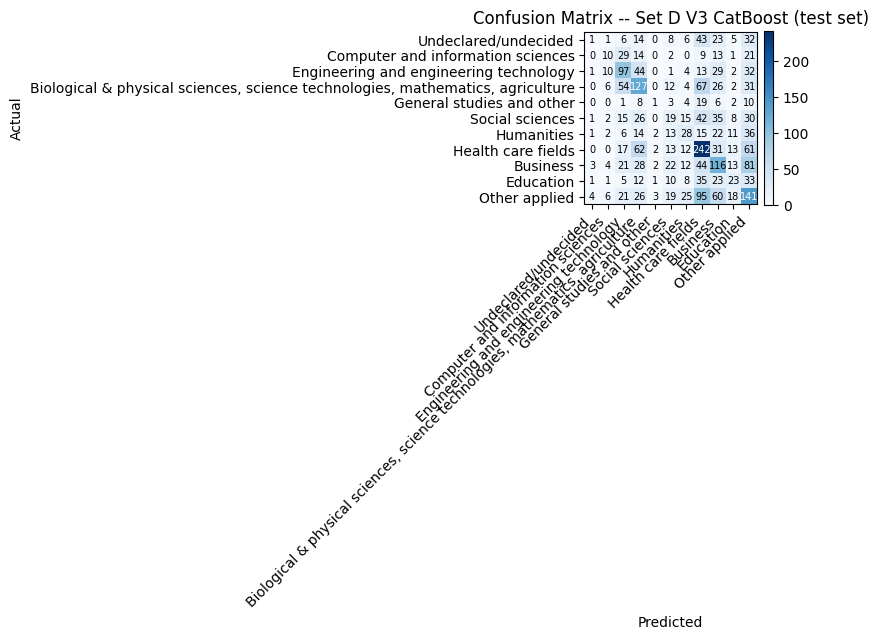

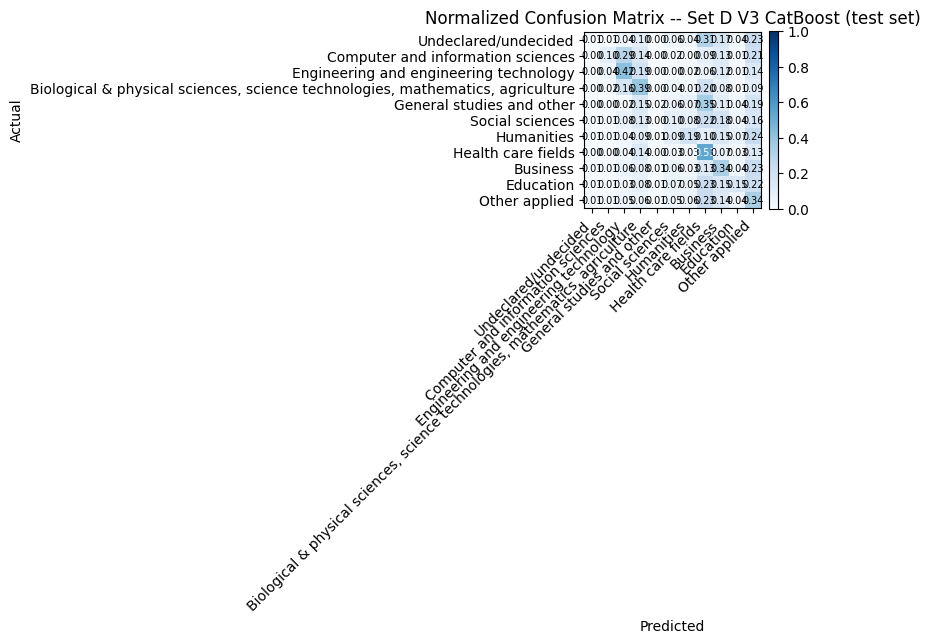

In [33]:
labels_sorted = sorted(pd.unique(np.concatenate([y_test, y_pred_test])).tolist())
display_labels_sorted = [display_label(l) for l in labels_sorted]

cm = confusion_matrix(y_test, y_pred_test, labels=labels_sorted)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

report_dict = classification_report(y_test, y_pred_test, labels=labels_sorted,
                                     target_names=display_labels_sorted,
                                     output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(out_path("setD_v3_catboost_classification_report.csv"))
print(classification_report(y_test, y_pred_test, labels=labels_sorted,
                             target_names=display_labels_sorted, zero_division=0))
print("Saved: setD_v3_catboost_classification_report.csv")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(display_labels_sorted))); ax.set_xticklabels(display_labels_sorted, rotation=45, ha="right")
ax.set_yticks(range(len(display_labels_sorted))); ax.set_yticklabels(display_labels_sorted)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix -- Set D V3 CatBoost (test set)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(out_path("fig_confusion_matrix.png"), dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(display_labels_sorted))); ax.set_xticklabels(display_labels_sorted, rotation=45, ha="right")
ax.set_yticks(range(len(display_labels_sorted))); ax.set_yticklabels(display_labels_sorted)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Normalized Confusion Matrix -- Set D V3 CatBoost (test set)")
for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        ax.text(j, i, f"{cm_normalized[i, j]:.2f}", ha="center", va="center",
                color="white" if cm_normalized[i, j] > 0.5 else "black", fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(out_path("fig_confusion_matrix_normalized.png"), dpi=200)
plt.show()


In [34]:
# Programmatic identification -- nothing below is manually asserted.
class_f1 = report_df.loc[display_labels_sorted, "f1-score"].astype(float)
class_recall = report_df.loc[display_labels_sorted, "recall"].astype(float)
class_support = report_df.loc[display_labels_sorted, "support"].astype(float)

best_classes = class_f1.sort_values(ascending=False).head(3)
worst_classes = class_f1.sort_values(ascending=True).head(3)
lowest_recall_classes = class_recall.sort_values(ascending=True).head(3)

print("Best-performing classes by F1:")
print(best_classes)
print("\nWorst-performing classes by F1:")
print(worst_classes)
print("\nClasses with lowest recall:")
print(lowest_recall_classes)

# Most frequent off-diagonal confusion pairs (human-readable labels where available)
cm_df = pd.DataFrame(cm, index=display_labels_sorted, columns=display_labels_sorted)
pairs = []
for actual in display_labels_sorted:
    for predicted in display_labels_sorted:
        if actual != predicted and cm_df.loc[actual, predicted] > 0:
            pairs.append({"Actual": actual, "Predicted": predicted, "Count": int(cm_df.loc[actual, predicted])})
confusion_pairs_df = pd.DataFrame(pairs).sort_values("Count", ascending=False)
print("\nTop 10 most frequent off-diagonal confusion pairs:")
print(confusion_pairs_df.head(10).to_string(index=False))


Best-performing classes by F1:
Health care fields                                                                0.449396
Engineering and engineering technology                                            0.384158
Biological & physical sciences, science technologies, mathematics, agriculture    0.360795
Name: f1-score, dtype: float64

Worst-performing classes by F1:
Undeclared/undecided         0.013245
General studies and other    0.030769
Social sciences              0.120635
Name: f1-score, dtype: float64

Classes with lowest recall:
Undeclared/undecided         0.007194
General studies and other    0.018519
Social sciences              0.098446
Name: recall, dtype: float64

Top 10 most frequent off-diagonal confusion pairs:
                                                                        Actual                                                                      Predicted  Count
                                                                 Other applied                    

## SHAP analysis: setup

SHAP explains the fitted CatBoost model on **original held-out test observations only**
(never on SMOTE-generated synthetic training rows, which do not correspond to real
students). The feature matrix passed to SHAP is produced by applying the pipeline's
*fitted* `preprocess` and `scale` steps to `X_test_raw` -- the same transformation the
model actually sees at prediction time -- via `TreeExplainer`, the appropriate SHAP
implementation for CatBoost (no `KernelExplainer` needed).

Because this is multiclass, the returned SHAP array's shape is explicitly inspected
before anything is aggregated -- multiclass SHAP output is not assumed to look like the
binary case.

In [35]:
feature_names = prep["feature_names"]
n_features = len(feature_names)

# Apply the FITTED preprocessing/scaling steps from the trained pipeline -- this is the
# exact transformation the model receives, not a re-derived equivalent. The "smote" step
# is intentionally skipped: SMOTE only resamples during .fit(), never during .transform()
# / .predict(), so real test rows are never synthetically altered.
X_test_transformed = pipe.named_steps["preprocess"].transform(prep["X_test_raw"])
X_test_transformed = pipe.named_steps["scale"].transform(X_test_transformed)

# The native fitted CatBoostClassifier inside the CatBoostEarlyStop wrapper.
catboost_native_model = pipe.named_steps["model"].model_

explainer = shap.TreeExplainer(catboost_native_model)
raw_shap = explainer.shap_values(X_test_transformed)

print("Type of SHAP output:", type(raw_shap))
if isinstance(raw_shap, list):
    print(f"List of {len(raw_shap)} arrays (one per class), each shape {raw_shap[0].shape}")
    shap_values_by_class = raw_shap
elif isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
    print(f"Single ndarray, shape {raw_shap.shape}")
    # TreeExplainer for CatBoost multiclass commonly returns (n_samples, n_features, n_classes).
    if raw_shap.shape[1] == n_features:
        shap_values_by_class = [raw_shap[:, :, c] for c in range(raw_shap.shape[2])]
    elif raw_shap.shape[2] == n_features:
        shap_values_by_class = [raw_shap[:, c, :] for c in range(raw_shap.shape[1])]
    else:
        raise RuntimeError(
            f"SHAP array shape {raw_shap.shape} does not match n_features={n_features} "
            f"on either axis 1 or 2 -- cannot safely resolve class/feature axes."
        )
else:
    raise RuntimeError(f"Unexpected SHAP output type/shape: {type(raw_shap)} -- cannot proceed safely.")

n_classes_shap = len(shap_values_by_class)
for sv in shap_values_by_class:
    assert sv.shape == (X_test_transformed.shape[0], n_features), (
        f"Per-class SHAP array shape {sv.shape} does not match "
        f"(n_test_samples={X_test_transformed.shape[0]}, n_features={n_features})"
    )
print(f"\nResolved to {n_classes_shap} per-class SHAP arrays, each shape {shap_values_by_class[0].shape}")

# --- Class order: do NOT assume the encoded target value equals the positional index
# into shap_values_by_class. Explicitly retrieve CatBoost's own class ordering and use
# it everywhere a SHAP class array must be matched to a specific target class. ---
shap_class_labels = list(catboost_native_model.classes_)
assert len(shap_class_labels) == len(shap_values_by_class)
print("CatBoost/SHAP class order:", shap_class_labels)


Type of SHAP output: <class 'numpy.ndarray'>
Single ndarray, shape (2566, 377, 11)

Resolved to 11 per-class SHAP arrays, each shape (2566, 377)
CatBoost/SHAP class order: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


## Global SHAP importance

Mean absolute SHAP value, aggregated across held-out observations **and** target
classes (mean of each class's per-feature mean |SHAP|), joined to the HSLS variable
description and corrected educational dimension from `HSLS_SetE_feature_audit.csv`
(reference lookup only -- this join does not add, remove, or reweight predictors).

**Integrity check:** confirms all 377 Set D predictors are covered (not just the
332-predictor Set E subset), and reports how many descriptions/dimensions could not be
resolved.

Applied manually verified dimension mapping to 30 of 30 Top-30 variables (remaining predictors keep the audit-based mapping).
Integrity check: importance_df covers 377 predictors (expected 377). PASS

Dimension value counts (including any unresolved):
Corrected educational dimension
Academic performance/preparation    240
Demographic/SES controls             55
Career interests and aspirations     51
Behavioral/psychological factors     21
Skills and self-efficacy             10
Name: count, dtype: int64

Unmatched descriptions (from audit join): 0
Unmatched dimensions (from audit join):    0

0 predictors require dimension review -- full coverage confirmed.
 Rank    Variable  Mean absolute SHAP                                                                                                                                                                                                                                                                                                        

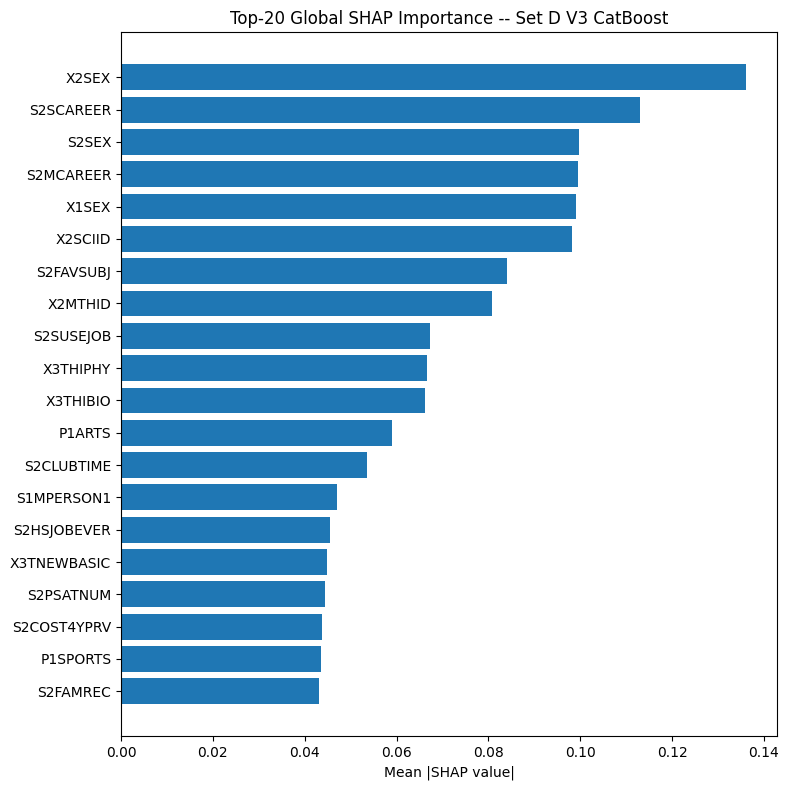

In [36]:
mean_abs_shap_per_class = np.stack([np.abs(sv).mean(axis=0) for sv in shap_values_by_class], axis=0)
mean_abs_shap_overall = mean_abs_shap_per_class.mean(axis=0)  # (n_features,)

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Mean absolute SHAP": mean_abs_shap_overall,
})

# Reference-only join: description + corrected dimension. Never used to alter the
# modelling feature set (already fixed above at 377 predictors). Uses the audit file,
# which covers all 377 Set D predictors (Set E's 332 kept + the 45 it removed) -- NOT
# the 332-row prepared Set E dataset.
if os.path.exists(SETE_AUDIT_PATH):
    audit_df = pd.read_csv(SETE_AUDIT_PATH)
    lookup = audit_df.set_index("Variable")[["Description", "Corrected Set E Dimension"]]
    importance_df = importance_df.join(lookup, on="Variable")
    importance_df["Corrected educational dimension"] = (
        importance_df["Corrected Set E Dimension"].map(DIMENSION_RENAME)
    )
    importance_df = importance_df.drop(columns=["Corrected Set E Dimension"])
else:
    print(f"WARNING: '{SETE_AUDIT_PATH}' not found -- descriptions/dimensions will be "
          f"marked for review instead of resolved.")
    importance_df["Description"] = None
    importance_df["Corrected educational dimension"] = None

n_unmatched_description = importance_df["Description"].isnull().sum()
n_unmatched_dimension = importance_df["Corrected educational dimension"].isnull().sum()

importance_df["Description"] = importance_df["Description"].fillna("Description requires review")
importance_df["Corrected educational dimension"] = importance_df["Corrected educational dimension"].fillna(
    "Dimension requires review"
)

importance_df = importance_df.sort_values("Mean absolute SHAP", ascending=False).reset_index(drop=True)
importance_df.insert(0, "Rank", range(1, len(importance_df) + 1))
importance_df = importance_df.rename(columns={
    "Description": "HSLS variable description",
})[["Rank", "Variable", "Mean absolute SHAP", "HSLS variable description", "Corrected educational dimension"]]

# --- Apply the manually verified Top-30 dimension mapping ---
# These 30 variables have been manually checked against the HSLS codebook and their
# dimension assignment overrides the automated audit-based mapping above. The
# remaining ~347 predictors keep the audit-based mapping (already confirmed to cover
# all 377 predictors with 0 unresolved -- see the integrity check below).
MANUAL_TOP30_DIMENSION_MAP = {
    "X2SEX": "Demographic/SES controls",
    "S2SCAREER": "Career interests and aspirations",
    "S2SEX": "Demographic/SES controls",
    "S2MCAREER": "Career interests and aspirations",
    "X1SEX": "Demographic/SES controls",
    "X2SCIID": "Skills and self-efficacy",
    "S2FAVSUBJ": "Career interests and aspirations",
    "X2MTHID": "Skills and self-efficacy",
    "S2SUSEJOB": "Career interests and aspirations",
    "X3THIPHY": "Academic performance/preparation",
    "X3THIBIO": "Academic performance/preparation",
    "P1ARTS": "Behavioral/psychological factors",
    "S2CLUBTIME": "Behavioral/psychological factors",
    "S1MPERSON1": "Skills and self-efficacy",
    "S2HSJOBEVER": "Demographic/SES controls",
    "X3TNEWBASIC": "Academic performance/preparation",
    "S2PSATNUM": "Academic performance/preparation",
    "S2COST4YPRV": "Demographic/SES controls",
    "P1SPORTS": "Behavioral/psychological factors",
    "S2FAMREC": "Demographic/SES controls",
    "S2SENJOYS": "Career interests and aspirations",
    "S2SATNUM": "Academic performance/preparation",
    "S1PLAN": "Career interests and aspirations",
    "S2FRFTJOB": "Demographic/SES controls",
    "S2FRCLGEXAM": "Demographic/SES controls",
    "X3THILANG": "Academic performance/preparation",
    "S1FYBA": "Career interests and aspirations",
    "P1EDUASPIRE": "Demographic/SES controls",
    "S2MUSEJOB": "Career interests and aspirations",
    "S1SUNDERST": "Skills and self-efficacy",
}
importance_df["Corrected educational dimension"] = importance_df.apply(
    lambda r: MANUAL_TOP30_DIMENSION_MAP.get(r["Variable"], r["Corrected educational dimension"]),
    axis=1,
)
n_manually_overridden = importance_df["Variable"].isin(MANUAL_TOP30_DIMENSION_MAP).sum()
print(f"Applied manually verified dimension mapping to {n_manually_overridden} of "
      f"{len(MANUAL_TOP30_DIMENSION_MAP)} Top-30 variables (remaining predictors keep "
      f"the audit-based mapping).")

# --- Integrity check ---
assert len(importance_df) == 377, f"Expected 377 predictors, found {len(importance_df)}"
print(f"Integrity check: importance_df covers {len(importance_df)} predictors (expected 377). PASS")
print(f"\nDimension value counts (including any unresolved):")
print(importance_df["Corrected educational dimension"].value_counts(dropna=False))
print(f"\nUnmatched descriptions (from audit join): {n_unmatched_description}")
print(f"Unmatched dimensions (from audit join):    {n_unmatched_dimension}")
n_review = (importance_df["Corrected educational dimension"] == "Dimension requires review").sum()
if n_review > 0:
    print(f"\n*** NOTE: {n_review} predictor(s) have 'Dimension requires review' -- "
          f"ideally 0 before final dimension aggregation. ***")
else:
    print(f"\n0 predictors require dimension review -- full coverage confirmed.")

# Display-only rename for readability -- the working column name and all
# calculations above are unchanged; only this saved/printed copy is relabeled.
display_importance_df = importance_df.rename(columns={"Corrected educational dimension": "Feature dimension"})
display_importance_df.to_csv(out_path("setD_v3_catboost_SHAP_global_importance.csv"), index=False)
print(display_importance_df.head(20).to_string(index=False))
print("\nSaved: setD_v3_catboost_SHAP_global_importance.csv")

top20 = importance_df.head(20)
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top20["Variable"][::-1], top20["Mean absolute SHAP"][::-1])
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top-20 Global SHAP Importance -- Set D V3 CatBoost")
plt.tight_layout()
plt.savefig(out_path("fig_SHAP_top20_global.png"), dpi=200)
plt.show()


### Interpretation note: repeated sex variables among top predictors

Student sex appears multiple times among the highest-ranked SHAP predictors through
`X2SEX`, `S2SEX`, and `X1SEX`. These variables represent highly related longitudinal
measurements of the same underlying demographic characteristic and should therefore
not be interpreted as three independent predictive factors. Their SHAP contributions
should be discussed as a consolidated demographic signal, while acknowledging that
correlated predictors can redistribute feature attribution. (These predictors are not
removed from the frozen model -- this is an interpretation note only.)

## SHAP beeswarm (Top-20)

A single conventional beeswarm is not well-defined for an 11-class model (each feature
would need 11 simultaneous SHAP-value distributions). Rather than force a plot that
misrepresents the model, this cell attempts a genuinely multiclass-valid summary first
and falls back to a clearly labelled **class-specific** beeswarm -- for the class with
the largest total mean |SHAP| among the top-20 features, i.e. the class this feature set
is most informative for -- if the multiclass form is not supported by the installed
SHAP version.

Multiclass beeswarm not supported by the installed SHAP version (The beeswarm plot does not support plotting explanations with instances that have more than one dimension!).
Falling back to a class-specific beeswarm for 'Engineering and engineering technology' (largest total top-20 mean |SHAP| among classes).


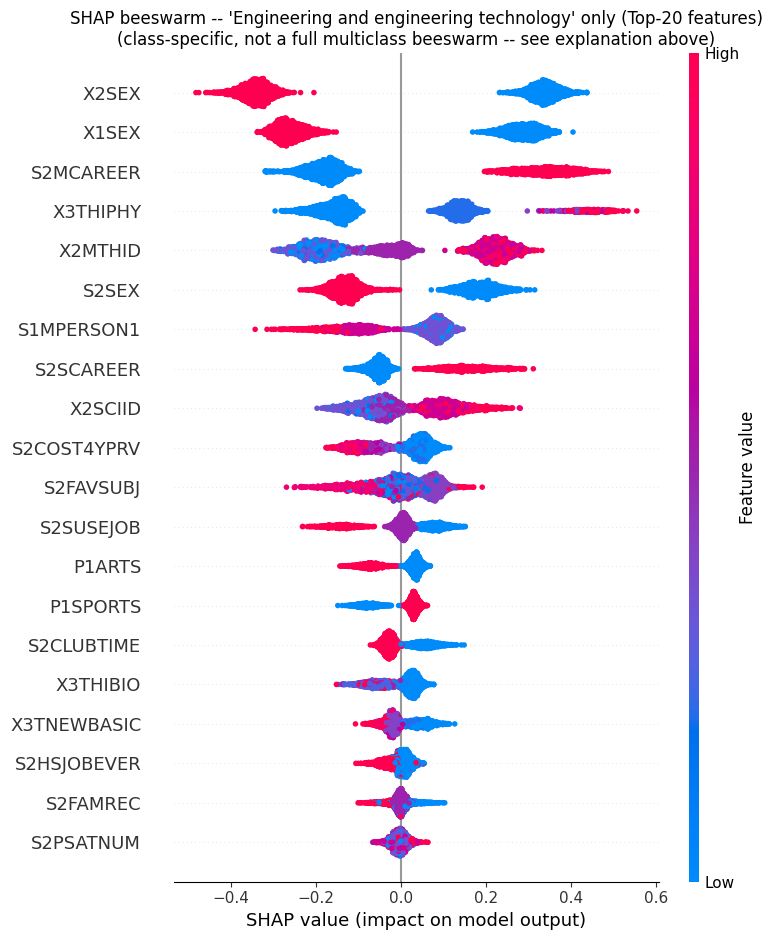

In [37]:
top20_idx = [feature_names.index(v) for v in top20["Variable"]]
top20_names = top20["Variable"].tolist()

multiclass_beeswarm_ok = False
try:
    exp = shap.Explanation(
        values=np.stack([sv[:, top20_idx] for sv in shap_values_by_class], axis=-1),
        data=X_test_transformed[:, top20_idx],
        feature_names=top20_names,
    )
    shap.plots.beeswarm(exp, show=False)
    plt.tight_layout()
    plt.savefig(out_path("fig_SHAP_beeswarm_top20.png"), dpi=200)
    plt.show()
    multiclass_beeswarm_ok = True
    print("Produced a multiclass-valid beeswarm.")
except Exception as e:
    print(f"Multiclass beeswarm not supported by the installed SHAP version ({e}).")

if not multiclass_beeswarm_ok:
    class_totals = mean_abs_shap_per_class[:, top20_idx].sum(axis=1)
    informative_class_idx = int(np.argmax(class_totals))
    informative_class_label = display_label(shap_class_labels[informative_class_idx])
    print(f"Falling back to a class-specific beeswarm for '{informative_class_label}' "
          f"(largest total top-20 mean |SHAP| among classes).")

    shap.summary_plot(
        shap_values_by_class[informative_class_idx][:, top20_idx],
        X_test_transformed[:, top20_idx],
        feature_names=top20_names,
        show=False,
    )
    plt.title(f"SHAP beeswarm -- '{informative_class_label}' only (Top-20 features)\n"
              f"(class-specific, not a full multiclass beeswarm -- see explanation above)")
    plt.tight_layout()
    plt.savefig(out_path("fig_SHAP_beeswarm_top20.png"), dpi=200)
    plt.show()


## Top-30 SHAP variables with manually verified dimensions

The Top-30 SHAP variables below reflect the **manually verified** dimension mapping
applied in the Global SHAP Importance step above (not the automated audit-based
mapping). This table is the corrected version of the earlier provisional review file.

In [38]:
top30_review = importance_df.head(30)[
    ["Rank", "Variable", "Mean absolute SHAP", "HSLS variable description", "Corrected educational dimension"]
].rename(columns={"Corrected educational dimension": "Feature dimension"})
top30_review.to_csv(out_path("SHAP_top30_dimension_review.csv"), index=False)
print(top30_review.to_string(index=False))
print("\nSaved: SHAP_top30_dimension_review.csv (manually verified dimension mapping applied)")


 Rank    Variable  Mean absolute SHAP                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

## Dimension-level SHAP (FINAL)

Both total and per-predictor-average mean |SHAP| are reported, since the five
dimensions contain very different numbers of predictors -- a dimension with more
predictors will tend to have a larger total even if no individual predictor in it is
especially informative.

This table uses the **manually verified** Top-30 dimension mapping (overriding the
automated audit-based mapping for those 30 variables) together with the audit-based
mapping for the remaining ~347 predictors, which was independently confirmed above to
cover all 377 predictors with zero unresolved entries.

*** FINAL -- manually verified Top-30 dimension mapping applied ***

               Feature dimension  Number of predictors  Total mean |SHAP|  Percentage of total SHAP  Average mean |SHAP| per predictor
Academic performance/preparation                   240           3.050768                     51.00                           0.012712
        Demographic/SES controls                    55           1.145162                     19.14                           0.020821
Career interests and aspirations                    51           1.001919                     16.75                           0.019645
Behavioral/psychological factors                    21           0.437471                      7.31                           0.020832
        Skills and self-efficacy                    10           0.347105                      5.80                           0.034711

Saved: SHAP_dimension_summary_FINAL.csv


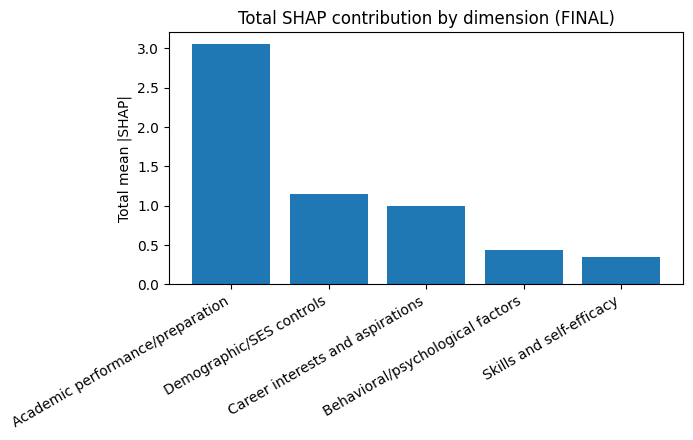

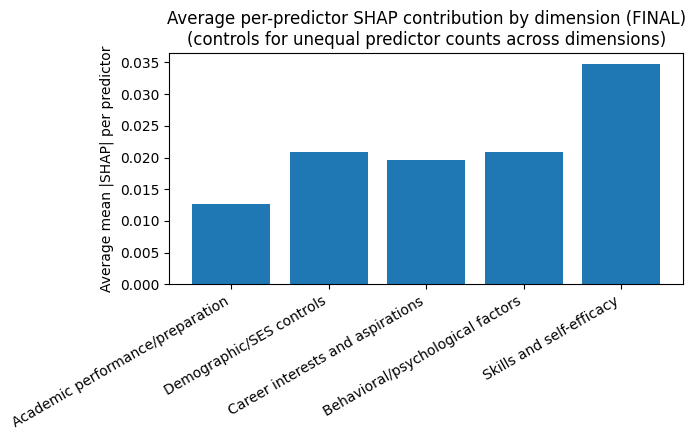

In [39]:
dim_group = importance_df.groupby("Corrected educational dimension").agg(
    **{
        "Number of predictors": ("Variable", "count"),
        "Total mean |SHAP|": ("Mean absolute SHAP", "sum"),
    }
)
dim_group["Percentage of total SHAP"] = (
    100 * dim_group["Total mean |SHAP|"] / dim_group["Total mean |SHAP|"].sum()
).round(2)
dim_group["Average mean |SHAP| per predictor"] = (
    dim_group["Total mean |SHAP|"] / dim_group["Number of predictors"]
)
dim_group = dim_group.sort_values("Total mean |SHAP|", ascending=False).reset_index()
# Display-only rename for readability -- the mapping/calculations above (including
# the manually verified Top-30 override) are unchanged; only this column label is renamed.
dim_group = dim_group.rename(columns={"Corrected educational dimension": "Feature dimension"})

print("*** FINAL -- manually verified Top-30 dimension mapping applied ***\n")
dim_group.to_csv(out_path("SHAP_dimension_summary_FINAL.csv"), index=False)
print(dim_group.to_string(index=False))
print("\nSaved: SHAP_dimension_summary_FINAL.csv")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(dim_group["Feature dimension"], dim_group["Total mean |SHAP|"])
ax.set_ylabel("Total mean |SHAP|")
ax.set_title("Total SHAP contribution by dimension (FINAL)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(out_path("fig_SHAP_dimension_total_FINAL.png"), dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(dim_group["Feature dimension"], dim_group["Average mean |SHAP| per predictor"])
ax.set_ylabel("Average mean |SHAP| per predictor")
ax.set_title("Average per-predictor SHAP contribution by dimension (FINAL)\n(controls for unequal predictor counts across dimensions)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(out_path("fig_SHAP_dimension_average_FINAL.png"), dpi=200)
plt.show()


## H2 evidence (evidence only -- not an automatic classification)

H2 proposed that career-interest and behavioral/psychological information would
contribute more strongly than academic information. This cell prints the
**manually-verified** dimension-level evidence -- it does not compute or print a
Supported / Partially Supported / Not Supported classification. That decision is made
explicitly elsewhere, based on this evidence, and reported cautiously.

**SHAP explains the model's predictions; it does not establish that any feature causes a
student to select a major.**

In [40]:
h2_evidence = dim_group.set_index("Feature dimension")[
    ["Total mean |SHAP|", "Average mean |SHAP| per predictor", "Percentage of total SHAP", "Number of predictors"]
]
print(h2_evidence.to_string())

print("\nFinal H2 interpretation should be based on the manually verified dimension "
      "results and reported cautiously.")


                                  Total mean |SHAP|  Average mean |SHAP| per predictor  Percentage of total SHAP  Number of predictors
Feature dimension                                                                                                                     
Academic performance/preparation           3.050768                           0.012712                     51.00                   240
Demographic/SES controls                   1.145162                           0.020821                     19.14                    55
Career interests and aspirations           1.001919                           0.019645                     16.75                    51
Behavioral/psychological factors           0.437471                           0.020832                      7.31                    21
Skills and self-efficacy                   0.347105                           0.034711                      5.80                    10

Final H2 interpretation should be based on the manuall

## Individual local explanations

One correctly classified test case and one misclassified test case, selected
programmatically (not cherry-picked). Any student-identifying columns are excluded from
the printed feature values. Titles use human-readable class labels when available.

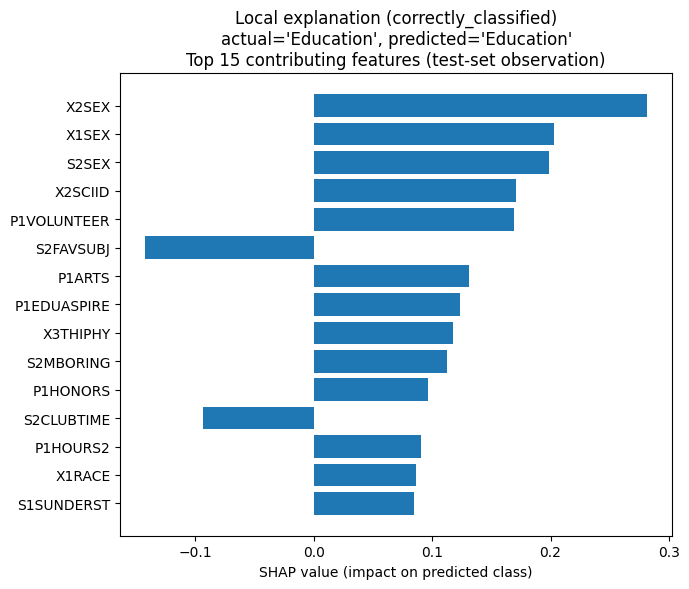

Saved: /content/drive/MyDrive/clean files/output3/fig_SHAP_local_correctly_classified.png


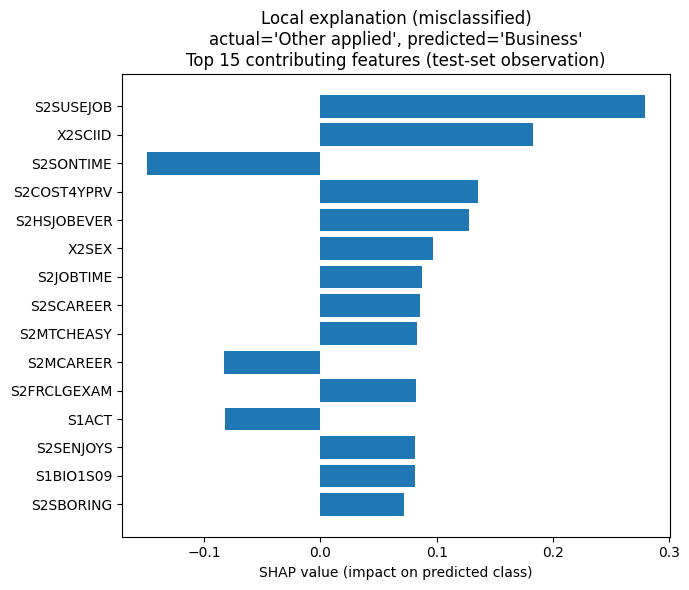

Saved: /content/drive/MyDrive/clean files/output3/fig_SHAP_local_misclassified.png


In [41]:
correct_mask = (y_pred_test == y_test)
misclassified_mask = ~correct_mask

rng = np.random.RandomState(RANDOM_STATE)
correct_indices = np.where(correct_mask)[0]
misclassified_indices = np.where(misclassified_mask)[0]

if len(correct_indices) == 0 or len(misclassified_indices) == 0:
    print("Cannot select both a correct and a misclassified case -- one group is empty.")
else:
    example_correct_pos = rng.choice(correct_indices)
    example_misclassified_pos = rng.choice(misclassified_indices)

    for label, pos in [("correctly_classified", example_correct_pos),
                        ("misclassified", example_misclassified_pos)]:
        predicted_class = y_pred_test[pos]
        actual_class = y_test[pos]
        # Do NOT assume the encoded class value equals the positional index into
        # shap_values_by_class -- look up the correct position via shap_class_labels.
        predicted_class_idx = shap_class_labels.index(predicted_class)
        sv_row = shap_values_by_class[predicted_class_idx][pos, :]

        order = np.argsort(-np.abs(sv_row))[:15]
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.barh(np.array(feature_names)[order][::-1], sv_row[order][::-1])
        ax.set_xlabel("SHAP value (impact on predicted class)")
        ax.set_title(f"Local explanation ({label})\n"
                     f"actual='{display_label(actual_class)}', predicted='{display_label(predicted_class)}'\n"
                     f"Top 15 contributing features (test-set observation)")
        plt.tight_layout()
        fname = out_path(f"fig_SHAP_local_{label}.png")
        plt.savefig(fname, dpi=200)
        plt.show()
        print(f"Saved: {fname}")


## Final reproducibility summary

Built entirely from variables already computed above -- nothing here is retyped.
Dimension-related fields now reflect the manually verified (FINAL) mapping. The H2
field states that final interpretation should be reported cautiously based on the
evidence above, rather than asserting a classification.

In [42]:
summary_dict = {
    "Dataset": DATA_PATH,
    "Target": TARGET_COL,
    "Number of records": len(prep["y_train"]) + len(prep["y_test"]),
    "Number of predictors": prep["n_features"],
    "Split": "80/20 stratified",
    "Random state": RANDOM_STATE,
    "Final model": "V3 CatBoost (imputed + scaled + SMOTE, untuned)",
    "Documented reference test Macro-F1": DOCUMENTED_V3_MACRO_F1,
    "Reproduced test Macro-F1": v3_row["F1 Test"],
    "Reproduction discrepancy": round(discrepancy, 4),
    "Dummy (most frequent) Macro-F1": baseline_comparison.set_index("Model").loc["Most Frequent", "Macro F1"],
    "Dummy (stratified) Macro-F1": baseline_comparison.set_index("Model").loc["Stratified", "Macro F1"],
    "CV Macro-F1 mean": cv_mean if cv_mean is not None else "Not available",
    "CV Macro-F1 SD": cv_std if cv_std is not None else "Not available",
    "CV source": cv_source,
    "Strongest classes (by F1)": ", ".join(str(c) for c in best_classes.index.tolist()),
    "Weakest classes (by F1)": ", ".join(str(c) for c in worst_classes.index.tolist()),
    "Top-10 SHAP features": ", ".join(importance_df.head(10)["Variable"].tolist()),
    "Dimension SHAP ranking (by total, FINAL)": ", ".join(dim_group["Feature dimension"].tolist()),
    "Predictors with 'Dimension requires review'": int(n_review),
    "H2 conclusion": "Final H2 interpretation should be based on the manually verified dimension results and reported cautiously.",
}

summary_df = pd.DataFrame(list(summary_dict.items()), columns=["Field", "Value"])
summary_df.to_csv(out_path("HSLS_final_SHAP_error_analysis_summary.csv"), index=False)
print(summary_df.to_string(index=False))
print("\nSaved: HSLS_final_SHAP_error_analysis_summary.csv")

# --- Explicit final print block, as requested ---
print("\n" + "=" * 70)
print("FINAL CLASS MAPPING")
print("=" * 70)
print(label_map_df.to_string(index=False))

print("\n" + "=" * 70)
print("CORRECTED TOP-30 DIMENSION MAPPING")
print("=" * 70)
print(top30_review.to_string(index=False))

print("\n" + "=" * 70)
print("FINAL DIMENSION SHAP SUMMARY")
print("=" * 70)
print(dim_group.to_string(index=False))

print("\n" + "=" * 70)
print("STRONGEST AND WEAKEST ACTUAL MAJOR CLASSES BY F1")
print("=" * 70)
print("Strongest:")
print(best_classes)
print("\nWeakest:")
print(worst_classes)

print("\n" + "=" * 70)
print("TOP-10 SHAP FEATURES")
print("=" * 70)
print(importance_df.head(10)[["Rank", "Variable", "Mean absolute SHAP", "Corrected educational dimension"]].rename(columns={"Corrected educational dimension": "Feature dimension"}).to_string(index=False))


                                      Field                                                                                                                                                    Value
                                    Dataset                                                                                         /content/drive/MyDrive/clean files/prepared_hsls_setD_4Y (3).csv
                                     Target                                                                                                                                           program_stream
                          Number of records                                                                                                                                                    12829
                       Number of predictors                                                                                                                                                      377
               

## Results Summary / RQ2 and H2 Finding

*(Written from the notebook's actual output above -- fill in with the specific figures
reported in the printed summary once run. No numeric value or dimension conclusion is
asserted here beyond what the executed cells produce.)*

- **Reproduction:** the fitted V3 CatBoost model's reproduced test Macro-F1 (see
  "Reproduce the selected model" above) either matches the documented reference
  (0.2287) within tolerance, or a discrepancy was flagged and should be investigated
  before treating downstream SHAP/error-analysis results as final.
- **Baselines:** the frozen model's Macro-F1 should be compared against both dummy
  baselines (see `final_model_vs_dummy_baselines.csv`) to establish genuine, non-trivial
  signal.
- **Error patterns:** the strongest/weakest classes and most frequent confusion pairs
  (see the class-level error analysis above, using the verified `X4ENTRYMAJ4Y` labels)
  describe where the model's predictive signal is concentrated and where it breaks
  down; any conceptual overlap between frequently confused classes is reported
  descriptively, not as a new class hierarchy.
- **RQ2 (which predictors matter):** the Top-20 global SHAP importance table and figure
  identify the predictors the model relies on most, with full 377-predictor coverage
  confirmed by the integrity check above. Note the repeated-sex-variable interpretation
  caveat above -- `X2SEX`, `S2SEX`, and `X1SEX` should be read as a consolidated
  demographic signal, not three independent factors.
- **H2 (FINAL, evidence-based, not auto-classified):** the dimension-level SHAP
  evidence is printed in the "H2 evidence" cell above, using the manually verified
  Top-30 dimension mapping. **No Supported / Partially Supported / Not Supported
  classification has been made by this notebook** -- per the final instruction, that
  classification is only made when explicitly instructed, based on this evidence,
  reported cautiously. SHAP explains the model's predictions; it does not establish
  causal influence on students' major choice.